Importing the Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

Importing The Boston House Price Dataset

In [2]:
hp = pd.read_csv("/content/boston.csv")

In [3]:
print(hp)

        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  \
0    0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296   
1    0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242   
2    0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242   
3    0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222   
4    0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
501  0.06263   0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273   
502  0.04527   0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273   
503  0.06076   0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273   
504  0.10959   0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273   
505  0.04741   0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273   

     PTRATIO       B  LSTAT  Price  
0       15.3  396.90   4.98   24.0  
1       17.8  396.90   9.14   21.6  
2       17.8

In [4]:
hp.shape

(506, 14)

In [5]:
hp.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


Statistical Measures of the dataset

In [6]:
hp.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


Understanding the Correlation Between Various Features in the Dataset
1) Positive Correlation - if one variable increases the other also increases
2) Negative Correlation - if one variable decreases the other also decreases

In [7]:
correlation = hp.corr()

<Axes: >

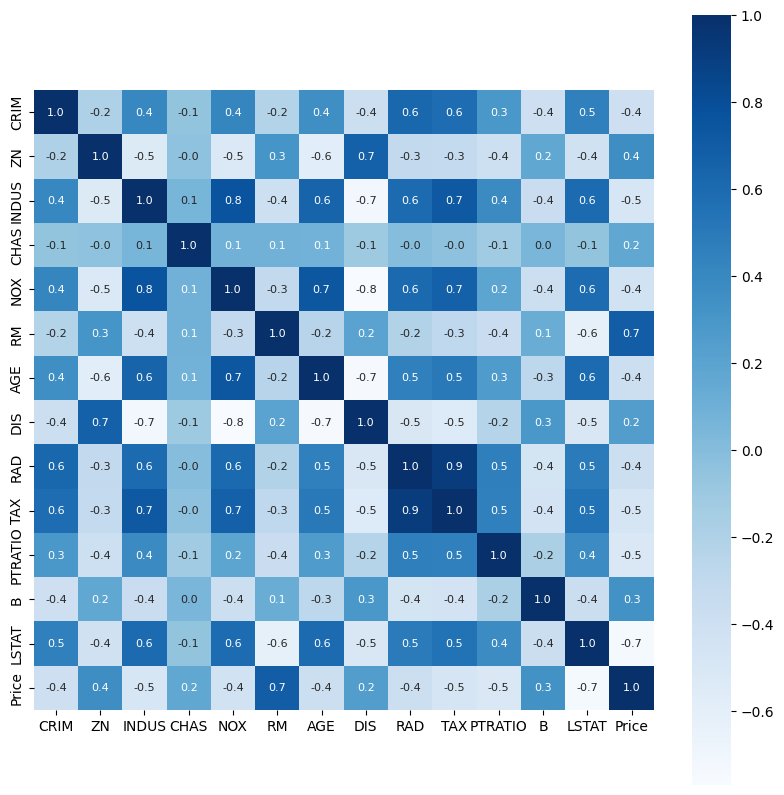

In [12]:
# Constructing a HeatMap to understand the correlation
plt.figure(figsize=(10,10),)
sns.heatmap(correlation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Blues')

Splitting The Data & Target

In [13]:
X = hp.drop(['Price'],axis=1)
Y = hp['Price']

In [14]:
print(X)
print(Y)

        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  \
0    0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296   
1    0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242   
2    0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242   
3    0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222   
4    0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
501  0.06263   0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273   
502  0.04527   0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273   
503  0.06076   0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273   
504  0.10959   0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273   
505  0.04741   0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273   

     PTRATIO       B  LSTAT  
0       15.3  396.90   4.98  
1       17.8  396.90   9.14  
2       17.8  392.83   4.03  
3  

Splitting The Data Into Training & Test Data

In [15]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state= 2)

In [16]:
print(X.shape,X_train.shape,X_test.shape)

(506, 13) (404, 13) (102, 13)


Model Training - XGBoost Regressor

In [17]:
model = XGBRegressor()

In [18]:
model.fit(X_train,Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluation

In [19]:
train_data_pred = model.predict(X_train)

In [20]:
print(train_data_pred)

[23.141842  20.983284  20.103428  34.69142   13.91575   13.498004
 21.998333  15.193665  10.903449  22.686766  13.80649    5.607422
 29.808262  50.005924  34.894993  20.60206   23.386408  19.204628
 32.70533   19.60305   26.996607   8.402646  45.998173  21.70041
 27.0927    19.390596  19.298737  24.807426  22.604942  31.701603
 18.530865   8.703727  17.404043  23.697786  13.300571  10.502583
 12.673761  24.997698  19.699127  14.902126  24.201878  24.992424
 14.909092  17.014936  15.591565  12.708229  24.512085  15.005392
 50.00175   17.518436  21.200298  32.01788   15.605521  22.894588
 19.31703   18.732553  23.298687  37.198833  30.092299  33.09997
 20.998034  49.99952   13.399705   5.0028057 16.498236   8.407585
 28.684132  19.504543  20.595694  45.407364  39.794533  33.402294
 19.80457   33.404335  25.296593  49.997654  12.51744   17.431204
 18.602709  22.599882  50.00823   23.817463  23.29894   23.096525
 41.701786  16.114292  31.620422  36.09577    7.0017447 20.381474
 20.00001   

In [21]:
# R Square
score_1 = metrics.r2_score(Y_train,train_data_pred)

#Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_train,train_data_pred)

# should be close to 0
print("R Square Error : ",score_1)

print("Mean Absolute Error : ",score_2)

R Square Error :  0.9999984582775392
Mean Absolute Error :  0.008061628530521298


Prediction on Test Data

In [22]:
test_data_pred = model.predict(X_test)
print(test_data_pred)

[22.787039  21.539017  29.978235  28.7926     9.404596  14.211495
 23.977915  25.166693  22.379875  20.114412  27.091932  25.370762
 20.779865  20.119997  11.467279  22.274008  19.467281  11.134231
  7.885436  14.200633  22.653477  20.163422  34.72723   18.788097
 18.201336  19.83425   38.61387   32.129185  34.78523   18.9034
 15.821682  20.207619  30.997856  23.609844  12.417964  18.86494
 10.469358  21.231272  22.363558  20.8838    24.905766  12.003266
 28.199202   9.0632105 20.161642  14.771794  35.51316   16.526493
 35.240414  15.448994  31.5936    23.08628    7.6087794 34.757496
 22.650396  20.824549  19.403572  20.288975  16.60615   22.609875
 20.77621   21.410755  19.285295  31.609272  35.04517   24.771255
 49.878265  27.676577  10.33637   24.000053  16.069407  10.32972
 16.720905  19.139389  26.620722  24.505224  21.99787   22.018208
 19.406097  24.87369   32.393536  17.085821  20.528683  31.145988
 48.7316    34.05933   17.161047  24.40791   30.378813  19.142971
 20.869547  20

In [23]:
# R Square
score_1 = metrics.r2_score(Y_test,test_data_pred)

#Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_test,test_data_pred)

# should be close to 0
print("R Square Error : ",score_1)

print("Mean Absolute Error : ",score_2)

R Square Error :  0.8771087539079264
Mean Absolute Error :  2.248779092115514


Visualizing Actual V/S Predicited Prices

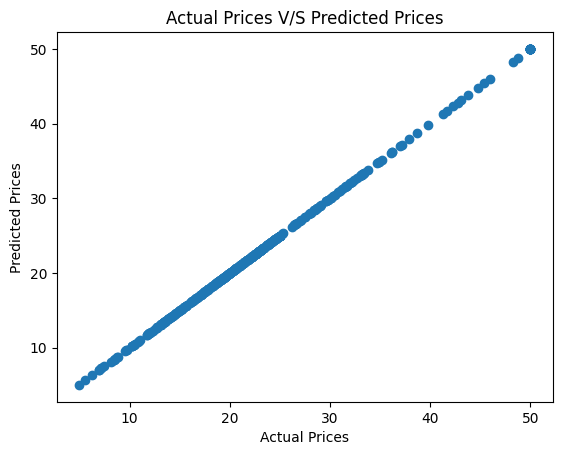

In [24]:
plt.scatter(Y_train,train_data_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices V/S Predicted Prices")
plt.show()